In [2]:
!pip install catboost joblib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.4 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

from catboost import CatBoostRegressor

import joblib

In [4]:
body = pd.read_csv("/content/body_dataset.csv")

body.head()

,gender,age,height,weight,neck,chest,waist,hip,shoulder_length,back_length,arm_length,leg_length,shoulder_width,torso_length,hip_length,back_center_length,BMI,BMI_Class,Age_Group,gender_label
0,M,41,1667,70.8,372,998,894,983,167,447.0,587.0,999,395,672,240,482.0,0.254778,저체중,40대,1
1,M,41,1656,58.8,366,946,745,901,134,423.0,549.0,1007,379,658,260,446.0,0.214416,저체중,40대,1
2,M,40,1729,65.6,377,972,838,907,137,443.0,550.0,1039,380,680,248,461.0,0.219439,저체중,40대,1
3,F,42,1685,70.4,331,993,885,998,135,397.0,560.0,1070,361,668,261,453.0,0.247955,저체중,40대,0
4,F,42,1602,50.1,304,818,718,922,121,368.0,525.0,985,335,611,234,391.0,0.195215,저체중,40대,0


In [5]:
body.columns

Index(['gender', 'age', 'height', 'weight', 'neck', 'chest', 'waist', 'hip',
       'shoulder_length', 'back_length', 'arm_length', 'leg_length',
       'shoulder_width', 'torso_length', 'hip_length', 'back_center_length',
       'BMI', 'BMI_Class', 'Age_Group', 'gender_label'],
      dtype='object')

In [6]:
body["gender"] = body["gender"].map({

    "남":0,
    "여":1,

    "남성":0,
    "여성":1
})

In [7]:
X = body[[
    "gender",
    "age",
    "height",
    "weight",
    "BMI"
]]

In [8]:
y = body[[
    "neck",
    "shoulder_width",
    "chest",
    "waist",
    "hip",
    "arm_length",
    "leg_length",
    "back_length",
    "torso_length",
    "hip_length",
    "back_center_length"
]]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42
)

In [10]:
models = {}

predictions = pd.DataFrame(index=y_test.index)

for col in y.columns:

    print(f"학습 중 : {col}")

    model = CatBoostRegressor(

        iterations=500,

        depth=6,

        learning_rate=0.05,

        loss_function="RMSE",

        verbose=False,

        random_seed=42

    )

    model.fit(X_train, y_train[col])

    pred = model.predict(X_test)

    predictions[col] = pred

    models[col] = model

학습 중 : neck
학습 중 : shoulder_width
학습 중 : chest
학습 중 : waist
학습 중 : hip
학습 중 : arm_length
학습 중 : leg_length
학습 중 : back_length
학습 중 : torso_length
학습 중 : hip_length
학습 중 : back_center_length


In [11]:
for col in y.columns:

    mae = mean_absolute_error(

        y_test[col],

        predictions[col]

    )

    r2 = r2_score(

        y_test[col],

        predictions[col]

    )

    print("="*40)

    print(col)

    print("MAE :", round(mae,2))

    print("R2 :", round(r2,3))

neck
MAE : 11.9
R2 : 0.798
shoulder_width
MAE : 11.97
R2 : 0.681
chest
MAE : 24.19
R2 : 0.859
waist
MAE : 27.25
R2 : 0.849
hip
MAE : 21.38
R2 : 0.737
arm_length
MAE : 12.97
R2 : 0.778
leg_length
MAE : 14.39
R2 : 0.89
back_length
MAE : 16.45
R2 : 0.559
torso_length
MAE : 16.89
R2 : 0.734
hip_length
MAE : 12.55
R2 : 0.407
back_center_length
MAE : 16.78
R2 : 0.574


In [12]:
joblib.dump(

    models,

    "body_prediction_model.pkl"

)

print("저장 완료")

저장 완료


In [13]:
models = joblib.load(

    "body_prediction_model.pkl"

)

In [14]:
user = pd.DataFrame({

    "gender":[0],

    "age":[24],

    "height":[175],

    "weight":[70],

    "BMI":[70/((175/100)**2)]

})

In [15]:
result_cm = {}

result = {}

for col, model in models.items():
    result[col] = model.predict(user)[0]

for key, value in result.items():
    result_cm[key] = round(value / 10, 1)

result_cm

{'neck': np.float64(36.3),
 'shoulder_width': np.float64(34.3),
 'chest': np.float64(97.9),
 'waist': np.float64(90.9),
 'hip': np.float64(104.3),
 'arm_length': np.float64(50.4),
 'leg_length': np.float64(91.7),
 'back_length': np.float64(39.1),
 'torso_length': np.float64(64.1),
 'hip_length': np.float64(25.3),
 'back_center_length': np.float64(47.9)}

In [16]:
result = {}

for col, model in models.items():

    result[col] = model.predict(user)[0]

result

{'neck': np.float64(363.36106595256183),
 'shoulder_width': np.float64(342.8971480705928),
 'chest': np.float64(978.7162894733198),
 'waist': np.float64(909.2610875416958),
 'hip': np.float64(1042.8154617227399),
 'arm_length': np.float64(503.97931094394767),
 'leg_length': np.float64(917.0699009878281),
 'back_length': np.float64(390.80951205228524),
 'torso_length': np.float64(640.8243292124413),
 'hip_length': np.float64(252.6671939790827),
 'back_center_length': np.float64(478.9597058594447)}

03_Pose_Analysis.**ipynb**

In [17]:
!pip install mediapipe opencv-python matplotlib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 89.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 8.7 MB/s eta 0:00:00


In [18]:
!pip install ultralytics opencv-python matplotlib -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 1.4 MB/s eta 0:00:00


In [19]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import numpy as np

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [20]:
# YOLO Pose 모델 로드
model = YOLO("yolov8n-pose.pt")

In [72]:
from google.colab import files

uploaded = files.upload()

Saving me.jpg to me.jpg


In [76]:
model = YOLO("yolov8n-pose.pt") # YOLO Pose 모델 로드

image_path = "me.jpg"

results = model.predict(
    image_path,
    conf=0.5
)


image 1/1 /content/me.jpg: 640x480 1 person, 213.3ms
Speed: 5.2ms preprocess, 213.3ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 480)


(np.float64(-0.5), np.float64(2999.5), np.float64(3999.5), np.float64(-0.5))

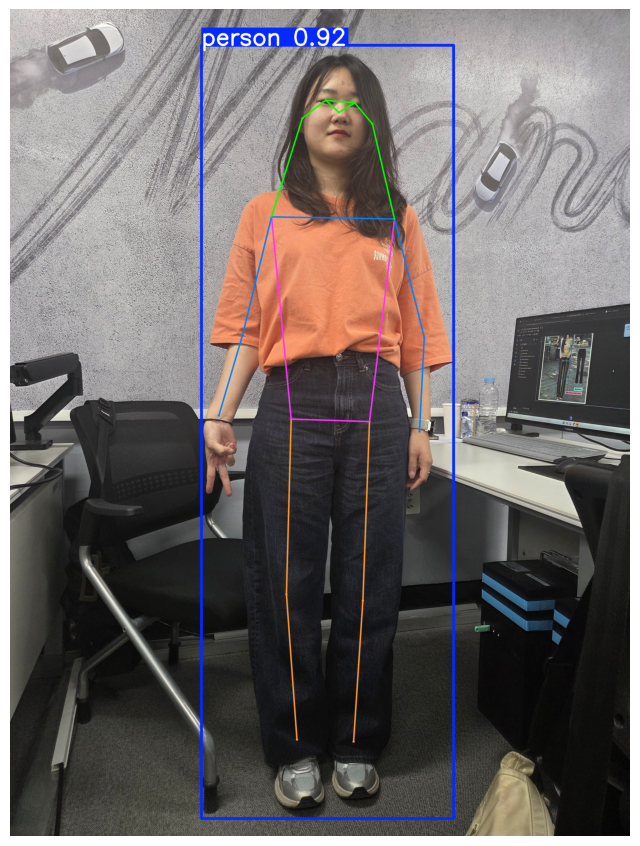

In [77]:
result = results[0]

img = result.plot()

plt.figure(figsize=(8,12))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")

In [24]:
keypoints = result.keypoints.xy.cpu().numpy()[0]

keypoints

array([[     537.05,      184.63],
       [      558.7,       163.4],
       [     514.68,      163.51],
       [     589.77,      170.33],
       [     482.99,      172.45],
       [     621.74,       297.5],
       [     445.85,       297.8],
       [     647.43,      453.18],
       [     405.16,      462.68],
       [     625.45,       535.5],
       [     426.58,      555.52],
       [     578.03,      654.04],
       [     461.76,         651],
       [     562.46,       972.5],
       [     459.66,      961.87],
       [     546.31,        1255],
       [     452.75,      1242.3]], dtype=float32)

In [25]:
NOSE = keypoints[0]

LEFT_SHOULDER = keypoints[5]
RIGHT_SHOULDER = keypoints[6]

LEFT_ELBOW = keypoints[7]
RIGHT_ELBOW = keypoints[8]

LEFT_WRIST = keypoints[9]
RIGHT_WRIST = keypoints[10]

LEFT_HIP = keypoints[11]
RIGHT_HIP = keypoints[12]

LEFT_KNEE = keypoints[13]
RIGHT_KNEE = keypoints[14]

LEFT_ANKLE = keypoints[15]
RIGHT_ANKLE = keypoints[16]

In [26]:
import math

def dist(a, b):
    return math.sqrt(
        (a[0]-b[0])**2 +
        (a[1]-b[1])**2
    )

In [27]:
shoulder = dist(
    LEFT_SHOULDER,
    RIGHT_SHOULDER
)

hip = dist(
    LEFT_HIP,
    RIGHT_HIP
)

arm = (
    dist(LEFT_SHOULDER, LEFT_ELBOW) +
    dist(LEFT_ELBOW, LEFT_WRIST)
)

leg = (
    dist(LEFT_HIP, LEFT_KNEE) +
    dist(LEFT_KNEE, LEFT_ANKLE)
)

torso = (
    dist(LEFT_SHOULDER, LEFT_HIP)
)

In [28]:
height = (
    dist(NOSE, LEFT_ANKLE)
)

ratio = {

    "shoulder_ratio": shoulder/height,

    "hip_ratio": hip/height,

    "arm_ratio": arm/height,

    "leg_ratio": leg/height,

    "torso_ratio": torso/height

}

ratio

{'shoulder_ratio': 0.16431625717261802,
 'hip_ratio': 0.10866011194757808,
 'arm_ratio': 0.22701162458253815,
 'leg_ratio': 0.5622062668752923,
 'torso_ratio': 0.3355904415597531}

04

In [29]:
import joblib
import numpy as np
import pandas as pd

In [30]:
models = joblib.load("body_prediction_model.pkl")

In [31]:
gender = 0
age = 24
height = 175
weight = 70

BMI = weight / ((height / 100) ** 2)

user = pd.DataFrame({

    "gender":[gender],

    "age":[age],

    "height":[height],

    "weight":[weight],

    "BMI":[BMI]

})

In [32]:

pred = {}

for name, model in models.items():

    pred[name] = model.predict(user)[0] / 10

pred

{'neck': np.float64(36.33610659525618),
 'shoulder_width': np.float64(34.289714807059276),
 'chest': np.float64(97.87162894733197),
 'waist': np.float64(90.92610875416958),
 'hip': np.float64(104.28154617227399),
 'arm_length': np.float64(50.397931094394764),
 'leg_length': np.float64(91.70699009878281),
 'back_length': np.float64(39.08095120522852),
 'torso_length': np.float64(64.08243292124413),
 'hip_length': np.float64(25.26671939790827),
 'back_center_length': np.float64(47.89597058594447)}

In [33]:
pose_ratio = {

    "shoulder_ratio":0.172912,

    "hip_ratio":0.129062,

    "arm_ratio":0.367263,

    "leg_ratio":0.544581,

    "torso_ratio":0.340302

}

In [34]:
AVG = {

    "shoulder_ratio":0.170,

    "hip_ratio":0.130,

    "arm_ratio":0.360,

    "leg_ratio":0.530,

    "torso_ratio":0.340

}

In [35]:
def correction(value, real, avg):

    scale = real / avg

    scale = np.clip(scale, 0.9, 1.1)

    return round(value * scale, 1)

In [36]:
final = {}

final["neck"] = pred["neck"]

final["shoulder_width"] = correction(
    pred["shoulder_width"],
    pose_ratio["shoulder_ratio"],
    AVG["shoulder_ratio"]
)

final["chest"] = correction(
    pred["chest"],
    pose_ratio["shoulder_ratio"],
    AVG["shoulder_ratio"]
)

final["waist"] = correction(
    pred["waist"],
    pose_ratio["hip_ratio"],
    AVG["hip_ratio"]
)

final["hip"] = correction(
    pred["hip"],
    pose_ratio["hip_ratio"],
    AVG["hip_ratio"]
)

final["arm_length"] = correction(
    pred["arm_length"],
    pose_ratio["arm_ratio"],
    AVG["arm_ratio"]
)

final["leg_length"] = correction(
    pred["leg_length"],
    pose_ratio["leg_ratio"],
    AVG["leg_ratio"]
)

final["back_length"] = correction(
    pred["back_length"],
    pose_ratio["torso_ratio"],
    AVG["torso_ratio"]
)

final["torso_length"] = correction(
    pred["torso_length"],
    pose_ratio["torso_ratio"],
    AVG["torso_ratio"]
)

final

{'neck': np.float64(36.33610659525618),
 'shoulder_width': np.float64(34.9),
 'chest': np.float64(99.5),
 'waist': np.float64(90.3),
 'hip': np.float64(103.5),
 'arm_length': np.float64(51.4),
 'leg_length': np.float64(94.2),
 'back_length': np.float64(39.1),
 'torso_length': np.float64(64.1)}

04_Body_Correction

In [37]:
import pandas as pd
import numpy as np
import joblib

In [38]:
body = pd.read_csv("/content/body_dataset.csv")

In [39]:
AVG = {

    "shoulder_ratio":
    body["shoulder_width"].mean()/body["height"].mean(),

    "hip_ratio":
    body["hip"].mean()/body["height"].mean(),

    "arm_ratio":
    body["arm_length"].mean()/body["height"].mean(),

    "leg_ratio":
    body["leg_length"].mean()/body["height"].mean(),

    "torso_ratio":
    body["torso_length"].mean()/body["height"].mean()

}

AVG

{'shoulder_ratio': np.float64(0.22530692873722158),
 'hip_ratio': np.float64(0.5743597214677268),
 'arm_ratio': np.float64(0.33227826065484717),
 'leg_ratio': np.float64(0.6123287569756531),
 'torso_ratio': np.float64(0.4011199318484864)}

In [40]:
models = joblib.load("body_prediction_model.pkl")

In [41]:
gender = 0
age = 24
height = 175
weight = 70

BMI = weight / ((height/100)**2)

user = pd.DataFrame({

    "gender":[gender],

    "age":[age],

    "height":[height],

    "weight":[weight],

    "BMI":[BMI]

})

In [42]:
pred = {}

for key, model in models.items():

    pred[key] = model.predict(user)[0]/10

pred

{'neck': np.float64(36.33610659525618),
 'shoulder_width': np.float64(34.289714807059276),
 'chest': np.float64(97.87162894733197),
 'waist': np.float64(90.92610875416958),
 'hip': np.float64(104.28154617227399),
 'arm_length': np.float64(50.397931094394764),
 'leg_length': np.float64(91.70699009878281),
 'back_length': np.float64(39.08095120522852),
 'torso_length': np.float64(64.08243292124413),
 'hip_length': np.float64(25.26671939790827),
 'back_center_length': np.float64(47.89597058594447)}

In [43]:
pose_ratio = {

 'shoulder_ratio':0.172912,

 'hip_ratio':0.129062,

 'arm_ratio':0.367263,

 'leg_ratio':0.544581,

 'torso_ratio':0.340302

}

In [44]:
def correction(value, pose_ratio, avg_ratio):

    scale = pose_ratio / avg_ratio

    scale = np.clip(scale, 0.90, 1.10)

    return round(value*scale,1)

In [45]:
final = {}

final["neck"] = pred["neck"]

final["shoulder_width"] = correction(
    pred["shoulder_width"],
    pose_ratio["shoulder_ratio"],
    AVG["shoulder_ratio"]
)

final["chest"] = correction(
    pred["chest"],
    pose_ratio["shoulder_ratio"],
    AVG["shoulder_ratio"]
)

final["waist"] = correction(
    pred["waist"],
    pose_ratio["hip_ratio"],
    AVG["hip_ratio"]
)

final["hip"] = correction(
    pred["hip"],
    pose_ratio["hip_ratio"],
    AVG["hip_ratio"]
)

final["arm_length"] = correction(
    pred["arm_length"],
    pose_ratio["arm_ratio"],
    AVG["arm_ratio"]
)

final["leg_length"] = correction(
    pred["leg_length"],
    pose_ratio["leg_ratio"],
    AVG["leg_ratio"]
)

final["back_length"] = correction(
    pred["back_length"],
    pose_ratio["torso_ratio"],
    AVG["torso_ratio"]
)

final["torso_length"] = correction(
    pred["torso_length"],
    pose_ratio["torso_ratio"],
    AVG["torso_ratio"]
)

pd.DataFrame(final,index=[0])

,neck,shoulder_width,chest,waist,hip,arm_length,leg_length,back_length,torso_length
0,36.336107,30.9,88.1,81.8,93.9,55.4,82.5,35.2,57.7


사용자가 입력하는 의류 정보

In [46]:
import pandas as pd

In [47]:
body = {

    "neck":36.5,

    "shoulder_width":43.7,

    "chest":99.4,

    "waist":80.2,

    "hip":96.7,

    "arm_length":57.8,

    "leg_length":93.2

}

In [48]:
cloth = {

    "length":71,

    "shoulder":45,

    "chest_half":53,

    "sleeve":62

}

In [49]:
cloth["chest"] = cloth["chest_half"] * 2

In [50]:
ease = {}

ease["shoulder"] = cloth["shoulder"] - body["shoulder_width"]

ease["chest"] = cloth["chest"] - body["chest"]

ease

{'shoulder': 1.2999999999999972, 'chest': 6.599999999999994}

In [51]:
def fit_level(ease):

    if ease < 0:
        return "작음"

    elif ease < 2:
        return "슬림핏"

    elif ease < 6:
        return "정사이즈"

    elif ease < 10:
        return "세미오버핏"

    else:
        return "오버핏"

In [52]:
fit = {

    "Shoulder":fit_level(ease["shoulder"]),

    "Chest":fit_level(ease["chest"])

}

fit

{'Shoulder': '슬림핏', 'Chest': '세미오버핏'}

In [53]:
def recommend_size(chest):

    if chest < 92:

        return "S"

    elif chest < 100:

        return "M"

    elif chest < 108:

        return "L"

    elif chest < 116:

        return "XL"

    else:

        return "2XL"

In [54]:
recommend_size(body["chest"])

'M'

In [55]:
print("="*40)

print("AI Fit Report")

print("="*40)

print()

print("추천 사이즈 :", recommend_size(body["chest"]))

print()

print("어깨 :", fit["Shoulder"])

print("가슴 :", fit["Chest"])

print()

print("어깨 여유 :", round(ease["shoulder"],1),"cm")

print("가슴 여유 :", round(ease["chest"],1),"cm")

AI Fit Report

추천 사이즈 : M

어깨 : 슬림핏
가슴 : 세미오버핏

어깨 여유 : 1.3 cm
가슴 여유 : 6.6 cm


In [56]:
# ==========================
# 사용자 입력
# ==========================

print("="*40)
print("사용자 정보를 입력하세요")
print("="*40)

gender_input = input("성별을 입력하세요 (남/여): ")

if gender_input == "남":
    gender = 0
else:
    gender = 1

age = int(input("나이 : "))
height = float(input("키(cm) : "))
weight = float(input("몸무게(kg) : "))

BMI = weight / ((height / 100) ** 2)

user = pd.DataFrame({
    "gender": [gender],
    "age": [age],
    "height": [height],
    "weight": [weight],
    "BMI": [BMI]
})
print("입력이 정상적으로 완료되었습니다.")

사용자 정보를 입력하세요
성별을 입력하세요 (남/여): 여
나이 : 26
키(cm) : 166
몸무게(kg) : 45
입력이 정상적으로 완료되었습니다.


In [57]:
import joblib

models = joblib.load("/content/body_prediction_model.pkl")

In [58]:
print(type(models))
print(models.keys())

<class 'dict'>
dict_keys(['neck', 'shoulder_width', 'chest', 'waist', 'hip', 'arm_length', 'leg_length', 'back_length', 'torso_length', 'hip_length', 'back_center_length'])


In [59]:
print(user)

   gender  age  height  weight        BMI
0       1   26   166.0    45.0  16.330382


In [60]:
pred = {}

for key, model in models.items():
    pred[key] = model.predict(user)[0] / 10

print(pred)

{'neck': np.float64(33.076231819075446), 'shoulder_width': np.float64(33.449145976091394), 'chest': np.float64(89.97642896324712), 'waist': np.float64(83.04172139990365), 'hip': np.float64(95.29144919216853), 'arm_length': np.float64(49.749153979091695), 'leg_length': np.float64(91.15081356603886), 'back_length': np.float64(38.10535350949506), 'torso_length': np.float64(60.948391222449104), 'hip_length': np.float64(24.15116174659455), 'back_center_length': np.float64(44.25182926465089)}


In [61]:
print("="*50)
print("        AI 신체 분석 결과")
print("="*50)

print(f"\n성별 : {'남성' if gender == 0 else '여성'}")
print(f"나이 : {age}세")
print(f"키 : {height} cm")
print(f"몸무게 : {weight} kg")
print(f"BMI : {BMI:.1f}")

if BMI < 18.5:
    body_type = "마른 체형"
elif BMI < 23:
    body_type = "표준 체형"
elif BMI < 25:
    body_type = "과체중"
elif BMI < 30:
    body_type = "비만"
else:
    body_type = "고도비만"

print(f"체형 : {body_type}")

print("\n[예측 신체 치수]")
print(f"목둘레       : {pred['neck']:.1f} cm")
print(f"어깨너비     : {pred['shoulder_width']:.1f} cm")
print(f"가슴둘레     : {pred['chest']:.1f} cm")
print(f"허리둘레     : {pred['waist']:.1f} cm")
print(f"엉덩이둘레   : {pred['hip']:.1f} cm")
print(f"팔길이       : {pred['arm_length']:.1f} cm")
print(f"다리길이     : {pred['leg_length']:.1f} cm")
print(f"등길이       : {pred['back_length']:.1f} cm")
print(f"몸통길이     : {pred['torso_length']:.1f} cm")

        AI 신체 분석 결과

성별 : 여성
나이 : 26세
키 : 166.0 cm
몸무게 : 45.0 kg
BMI : 16.3
체형 : 마른 체형

[예측 신체 치수]
목둘레       : 33.1 cm
어깨너비     : 33.4 cm
가슴둘레     : 90.0 cm
허리둘레     : 83.0 cm
엉덩이둘레   : 95.3 cm
팔길이       : 49.7 cm
다리길이     : 91.2 cm
등길이       : 38.1 cm
몸통길이     : 60.9 cm


In [62]:
print("="*50)
print("        AI 신체 분석 시스템")
print("="*50)

# 사용자 입력
gender_input = input("성별을 입력하세요 (남자/여자) : ").strip()

while gender_input not in ["남자", "여자"]:
    gender_input = input("잘못 입력했습니다. '남' 또는 '여'를 입력하세요 : ").strip()

gender = 0 if gender_input == "남" else 1

age = int(input("나이를 입력하세요 : "))
height = float(input("키(cm)를 입력하세요 : "))
weight = float(input("몸무게(kg)를 입력하세요 : "))

# BMI 계산
BMI = weight / ((height / 100) ** 2)

# 모델 입력용 DataFrame
user = pd.DataFrame({
    "gender": [gender],
    "age": [age],
    "height": [height],
    "weight": [weight],
    "BMI": [BMI]
})

# ==========================
# AI 예측
# ==========================
pred = {}

for key, model in models.items():
    pred[key] = model.predict(user)[0] / 10

# ==========================
# 결과 출력
# ==========================

print("\n")
print("="*50)
print("        AI 신체 분석 결과")
print("="*50)

print(f"성별 : {gender_input}")
print(f"나이 : {age}세")
print(f"키 : {height:.1f} cm")
print(f"몸무게 : {weight:.1f} kg")
print(f"BMI : {BMI:.1f}")

if BMI < 18.5:
    body_type = "마른 체형"
elif BMI < 23:
    body_type = "표준 체형"
elif BMI < 25:
    body_type = "과체중"
elif BMI < 30:
    body_type = "비만 체형"
else:
    body_type = "고도 비만"

print(f"체형 : {body_type}")

print("\n[예측 신체 치수]")
for k, v in pred.items():
    print(f"{k:20s}: {v:.1f} cm")

        AI 신체 분석 시스템
성별을 입력하세요 (남자/여자) : 여자
나이를 입력하세요 : 26
키(cm)를 입력하세요 : 166
몸무게(kg)를 입력하세요 : 45


        AI 신체 분석 결과
성별 : 여자
나이 : 26세
키 : 166.0 cm
몸무게 : 45.0 kg
BMI : 16.3
체형 : 마른 체형

[예측 신체 치수]
neck                : 33.1 cm
shoulder_width      : 33.4 cm
chest               : 90.0 cm
waist               : 83.0 cm
hip                 : 95.3 cm
arm_length          : 49.7 cm
leg_length          : 91.2 cm
back_length         : 38.1 cm
torso_length        : 60.9 cm
hip_length          : 24.2 cm
back_center_length  : 44.3 cm


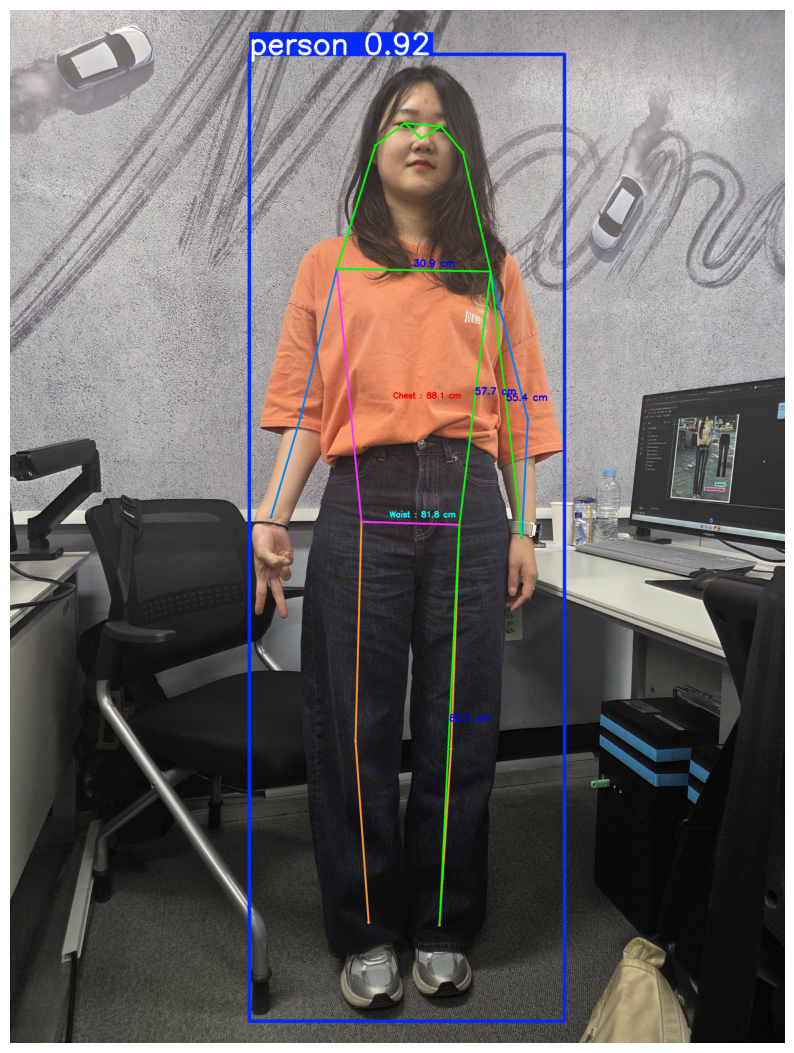

====== 예측 신체 치수 ======
neck                : 36.3 cm
shoulder_width      : 30.9 cm
chest               : 88.1 cm
waist               : 81.8 cm
hip                 : 93.9 cm
arm_length          : 55.4 cm
leg_length          : 82.5 cm
back_length         : 35.2 cm
torso_length        : 57.7 cm


In [89]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# 1. YOLO 예측 결과 이미지 가져오기 (result.plot()은 보통 원본 크기 혹은 리사이즈된 이미지를 반환함)
img = result.plot()

# 현재 plot()된 이미지의 실제 크기 확인
img_h, img_w, _ = img.shape

# 2. YOLO 내부에서 매핑된 원본 크기 기준의 키포인트 좌표 추출 (가장 확실한 방법)
# result.keypoints.xy[0]에 각 관절의 좌표가 들어있습니다. (Ultralytics YOLOv8 기준)
keypoints = result.keypoints.xy[0].cpu().numpy()

# YOLO keypoints 순서에 맞게 좌표 할당 (일반적인 COCO 데이터셋 기준 순서)
# 5: 왼어깨, 6: 오른어깨, 11: 왼골반, 12: 오른골반, 9: 왼손목, 15: 왼발목
LEFT_SHOULDER  = keypoints[5]
RIGHT_SHOULDER = keypoints[6]
LEFT_WRIST     = keypoints[9]
LEFT_HIP       = keypoints[11]
RIGHT_HIP      = keypoints[12]
LEFT_ANKLE     = keypoints[15]

# --------------------------
# 선과 글씨를 그리는 함수
# --------------------------
def draw_length(img, p1, p2, text):
    # 좌표가 유효한지 확인 (YOLO가 검출하지 못한 경우 0,0 일 수 있음)
    if np.sum(p1) == 0 or np.sum(p2) == 0:
        return

    p1 = tuple(np.int32(p1))
    p2 = tuple(np.int32(p2))

    # 선 그리기
    cv2.line(img, p1, p2, (0, 255, 0), 5)  # 이미지 크기가 크므로 두께를 5로 확장

    # 가운데 좌표 계산
    mid = (int((p1[0] + p2[0]) / 2), int((p1[1] + p2[1]) / 2))

    # 텍스트가 본(선) 바로 위에 살짝 떠 있도록 y좌표를 살짝 위로(-15) 조정
    text_pos = (mid[0], mid[1] - 15)

    # 글씨 쓰기 (이미지 해상도가 크다면 fontScale과 두께를 더 키워야 잘 보입니다)
    cv2.putText(
        img,
        text,
        text_pos,
        cv2.FONT_HERSHEY_SIMPLEX,
        1.2,        # 글자 크기 키움
        (255, 0, 0),
        3           # 글자 두께 키움
    )

# ================================
# 실제 예측된 cm 표시
# ================================

# 어깨
draw_length(img, LEFT_SHOULDER, RIGHT_SHOULDER, f"{final['shoulder_width']:.1f} cm")

# 왼팔
draw_length(img, LEFT_SHOULDER, LEFT_WRIST, f"{final['arm_length']:.1f} cm")

# 몸통
draw_length(img, LEFT_SHOULDER, LEFT_HIP, f"{final['torso_length']:.1f} cm")

# 왼다리
draw_length(img, LEFT_HIP, LEFT_ANKLE, f"{final['leg_length']:.1f} cm")

# 가슴 (어깨와 골반 중간 높이 기준)
chest_pos = (
    int((LEFT_SHOULDER[0] + RIGHT_SHOULDER[0]) / 2) - 80,
    int((LEFT_SHOULDER[1] + LEFT_HIP[1]) / 2)
)
cv2.putText(img, f"Chest : {final['chest']:.1f} cm", chest_pos, cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 0, 255), 3)

# 허리 (골반 살짝 위 기준)
waist_pos = (
    int((LEFT_HIP[0] + RIGHT_HIP[0]) / 2) - 80,
    int(LEFT_HIP[1] - 30)
)
cv2.putText(img, f"Waist : {final['waist']:.1f} cm", waist_pos, cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255, 255, 0), 3)

# 출력
plt.figure(figsize=(10, 15))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

print("====== 예측 신체 치수 ======")
for k, v in final.items():
    print(f"{k:20s}: {v:.1f} cm")

In [84]:
print(LEFT_SHOULDER)
print(img.shape)

[     621.74       297.5]
(4000, 3000, 3)
